## MNIST Dataset: Classification and Ensemble Learning

In this notebook, we explore several machine learning classifiers using the MNIST handwritten digit dataset. We begin by loading and preprocessing the data, followed by training baseline classification models. We then improve model performance through hyperparameter tuning and compare the results across different algorithms. Finally, we investigate ensemble learning by combining multiple weaker classifiers and evaluating whether the ensemble outperforms the individual models.


#### Import Tensorflow, keras and MNIST dataset

In [3]:
import tensorflow as tf
from tensorflow import keras 
import keras
from keras import layers
import keras_tuner
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

#### Load all other libraries for pre-processing and modelling

In [4]:
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#### Preprocessing

We will need a validation set in some cases, however we will rely on k-fold cross validation mostly. 

In [5]:
# Create a validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)

Code for preprocessing adapted from [Keras Documentation: Simple MNIST convnet](#https://keras.io/examples/vision/mnist_convnet/). 

In [6]:
# Preprocess images, they need to be scalled and reshaped
# Scale images to the [0, 1] range
X_train = X_train.astype("float32") / 255
X_val = X_val.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Flatten images - most models require input to be in 2D
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("X_train shape:", X_train.shape)
print(X_train.shape[0], "train samples")
print(X_val.shape[0], "val samples")
print(X_test.shape[0], "test samples")

X_train shape: (42000, 784)
42000 train samples
18000 val samples
10000 test samples


The resulting shape is one vector 28x28 = 784 pixel values for each image. This format is generally needed for classifiers like KNN, Logistic Regression and others.   

### Baseline Modelling and Hyperparameter Tuning

We begin by training each classifier individually to establish baseline performance using the default hyperparameters. We then perform hyperparameter tuning to optimize each model and compare their performance. Finally, the best-performing classifiers are selected and combined into an ensemble model to evaluate whether they achieve better predictive performance than the individual classifiers.

Code and information on different hyperparameters adapted from [Towards Data Science: Machine Learning Mastery](#https://machinelearningmastery.com/hyperparameters-for-classification-machine-learning-algorithms/). Additional information on how each parameter influences the training process is taken from [Towards Data Science: SVM Hyperparameters Explained with Visualizations](#https://towardsdatascience.com/svm-hyperparameters-explained-with-visualizations-143e48cb701b/)

#### Logistic Regression

In [7]:
# Logistic Regression
log_reg = LogisticRegression(random_state=42)

# Fitting the model
log_reg.fit(X_train, y_train)

# Predictions on validation set 
y_train_pred = log_reg.predict(X_train)
y_val_pred = log_reg.predict(X_val)

# Accuracy
print('Logistic Regression training accuracy:', accuracy_score(y_train, y_train_pred))
print('Logistic Regression validation accuracy:', accuracy_score(y_val, y_val_pred))

Logistic Regression training accuracy: 0.9370952380952381
Logistic Regression validation accuracy: 0.9206666666666666


#### Hyperparameter optimization for Logistic Regression 

In [8]:
# Define parameters 
solvers = ['newton-cg', 'lbfgs', 'liblinear']  
penalty = ['l2', 'l1'] # regularization parameter
c_values = [100, 10, 1.0, 0.1, 0.01] # different values of C - controls regularization strenght 

# Grid search - searches the best parameters among the ones we specified above
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=log_reg, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)

# Summarize results
print("Best accuracy: %f using the following hyperparameters %s" % (grid_result.best_score_, grid_result.best_params_))

Best accuracy: 0.919746 using the following hyperparameters {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}


In [9]:
# Save for later use
log_reg_params = grid_result.cv_results_['params']
log_reg_params[0]

{'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}

#### K-NN

In [10]:
# K-NN
knn = KNeighborsClassifier()

# Fit the model
knn.fit(X_train, y_train)

# Predictions
y_train_pred = knn.predict(X_train)
y_val_pred = knn.predict(X_val)

# Accuracy
print('KNN training accuracy:', accuracy_score(y_train, y_train_pred))
print('KNN validation accuracy:', accuracy_score(y_val, y_val_pred))

KNN training accuracy: 0.9795
KNN validation accuracy: 0.9677222222222223


#### Hyperparameter optimization for K-NN

In [11]:
# Parameters
n_neighbors = range(1, 21, 2) # number of neighbours
weights = ['uniform', 'distance'] # different distance metrics 
metric = ['euclidean', 'manhattan', 'minkowski'] # different weightings 

# Define grid search
grid = dict(n_neighbors=n_neighbors,weights=weights,metric=metric)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=knn, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)

# Summarize results
print("Best accuracy: %f using the following hyperparameters %s" % (grid_result.best_score_, grid_result.best_params_))

Best accuracy: 0.968778 using the following hyperparameters {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


In [28]:
# Save for later
knn_params = grid_result.cv_results_['params'] 

#### Support Vector Machines (SVM)

In [21]:
# SVM 
svm = SVC(random_state=42)

# Fit the model
svm.fit(X_train, y_train)

# Predictions
y_train_pred = svm.predict(X_train)
y_val_pred = svm.predict(X_val)

# Accuracy
print('SVM Training accuracy:', accuracy_score(y_train, y_train_pred))
print('SVM Validation accuracy:', accuracy_score(y_val, y_val_pred))


SVM Training accuracy: 0.9878571428571429
SVM Validation accuracy: 0.975


#### Hyperparameter optimization for SVM

In [22]:
# Define hyperparameters 
kernel = ['linear', 'poly', 'rbf', 'sigmoid'] # different kernels
C = [50, 10, 1.0, 0.1, 0.01] # impacts the regions of the classes
gamma = ['scale', 'auto'] # impacts the distance of the influence of each data point  

# Define grid search
grid = dict(kernel=kernel,C=C,gamma=gamma)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=svm, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)
# Summarize results
print("Best accuracy: %f using the following hyperparameters %s" % (grid_result.best_score_, grid_result.best_params_))

Best accuracy: 0.977063 using the following hyperparameters {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}


In [27]:
# For later
svm_params = grid_result.cv_results_['params']

#### Descion Tree 

In [139]:
# Desicion Tree 
dt = tree.DecisionTreeClassifier()

# Fitting the model
dt.fit(X_train, y_train)

# Predictions
y_train_pred = dt.predict(X_train)
y_val_pred = dt.predict(X_val)

# Accuracy
print('Decision Tree training accuracy:', accuracy_score(y_train, y_train_pred))
print('Decision Tree validation accuracy:', accuracy_score(y_val, y_val_pred))

Decision Tree training accuracy: 1.0
Decision Tree validation accuracy: 0.8644444444444445


(!) This results indicate that the decision tree model is likely overfitting the train set. 

#### Hyperparameter optimization for Decision Tree

Code and information on different parameters adapted from [How to tune a Decision Tree in Hyperparameter tuning](#https://www.geeksforgeeks.org/machine-learning/how-to-tune-a-decision-tree-in-hyperparameter-tuning/). 

In [117]:
max_depth = [10, 20, 30, None] # maximum lenght to which a tree is allowed to grow
min_samples_split = [2, 5, 10] # minumum number of samples to split the node 
min_samples_leaf = [1, 2, 4] # minimal number of samples in a splitted node

# Define grid search
grid = dict(max_depth = max_depth,min_samples_split=min_samples_split,min_samples_leaf=min_samples_leaf)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=dt, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)
# Summarize results
print("Best accuracy: %f using the following hyperparameters %s" % (grid_result.best_score_, grid_result.best_params_))

Best accuracy: 0.803967 using the following hyperparameters {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [118]:
# Might use in ensemble learning 
tree_params = grid_result.cv_results_['params']
tree_params[0]

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

##### Naive Bayes

To find the most appropriate classifiers for the datset, we consulted: [Sklearn Documentation: Naive Bayes](#https://scikit-learn.org/stable/modules/naive_bayes.html). 

In [119]:
# Gaussian Naive Bayes
gnb = GaussianNB()

y_pred = gnb.fit(X_train, y_train)

# Predictions
y_train_pred = gnb.predict(X_train)
y_val_pred = gnb.predict(X_val)

# Accuracy
print('Naive Bayes training accuracy:', accuracy_score(y_train, y_train_pred))
print('Naive Bayes validation accuracy:', accuracy_score(y_val, y_val_pred))

Naive Bayes training accuracy: 0.5623095238095238
Naive Bayes validation accuracy: 0.5577777777777778


Gaussian Naive Bayes in this case performed a little better than chance. We will try to improve this result with hyperparameter tuning. 

##### Gaussian Naive Bayes with tuned hyperparameters

Information on what hyperparameters to tune for Naive Bayes was taken from: [Data Science Solutions](https://www.youtube.com/watch?v=-vyKkjqpMwA)

In [120]:
# Define hyperparameters
var_smoothing = np.logspace(0, -9, num=100) # adds a value to the distribution variance

# Define grid search
grid = dict(var_smoothing=var_smoothing)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=gnb, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train, y_train)
# Summarize results
print("Best accuracy: %f using the following hyperparameters %s" % (grid_result.best_score_, grid_result.best_params_))

Best accuracy: 0.816800 using the following hyperparameters {'var_smoothing': np.float64(0.0533669923120631)}


In [121]:
gnb_params = grid_result.cv_results_['params']
gnb_params[0]

{'var_smoothing': np.float64(1.0)}

This significantly improved test accuracy when comparining to the default hyperparameters applied to train and validation set.  

#### Convolutional Neural Networks (CNNs)

For Convolutional Neural Networks (CNNs), the data requires additional preprocessing compared with the previous models. While the image pixel values are still scaled, the input images must be reshaped to include a channel dimension expected by CNNs. In addition, the target labels are converted from integer class labels to one-hot encoded vectors, which are required for multi-class classification using categorical cross-entropy loss.

The preprocessing steps were adapted from the Keras example: [Keras Documentation: Simple MNIST convnet](#https://keras.io/examples/vision/mnist_convnet/). 

In [154]:
# Download the data again
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [155]:
# Data preparation for CNNs
num_classes = 10
input_shape = (28, 28, 1)

# Scale images to the [0, 1] range
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
X_train_cnn = np.expand_dims(X_train, -1)
X_test_cnn = np.expand_dims(X_test, -1)
print("X_train shape:", X_train_cnn.shape)
print(X_train_cnn.shape[0], "train samples")
print(X_test_cnn.shape[0], "test samples")

# Convert class vectors to binary class matrices
y_train_cnn = keras.utils.to_categorical(y_train, num_classes)
y_test_cnn = keras.utils.to_categorical(y_test, num_classes)

X_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


Code for the model architecture is taken from [Keras Documentation: Simple MNIST convnet](#https://keras.io/examples/vision/mnist_convnet/). 

In this architecture, we have the following components: 

1. The input layer which takes in images in the shape of (28, 28, 1). 
2. The first convolutional layer which does feature detection and the ReLu activation function. 
3. The maxpooling layers which downsamples the output of previous layer. 
4. The second convolutional layers with Relu activation function. 
5. Second maxpooling layer. 
6. Flatten layers which turns tensors into a vector. 
7. The dropout layer which sets half of the activations to zero, controlling for overfitting.  
8. Dense layer with softmax function to calculate probabilities for each class. 

In [156]:
# Define a network CNNs
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"), 
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"), # since we have multiclass 
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [157]:
batch_size = 128
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(X_train_cnn, y_train_cnn, batch_size=batch_size, epochs=epochs, validation_split=0.15)

Epoch 1/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8810 - loss: 0.3928 - val_accuracy: 0.9768 - val_loss: 0.0957
Epoch 2/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9644 - loss: 0.1184 - val_accuracy: 0.9837 - val_loss: 0.0636
Epoch 3/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9732 - loss: 0.0868 - val_accuracy: 0.9842 - val_loss: 0.0558
Epoch 4/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9777 - loss: 0.0716 - val_accuracy: 0.9871 - val_loss: 0.0485
Epoch 5/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9801 - loss: 0.0639 - val_accuracy: 0.9878 - val_loss: 0.0445
Epoch 6/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9829 - loss: 0.0558 - val_accuracy: 0.9892 - val_loss: 0.0395
Epoch 7/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9835 - loss: 0.0519 - val_accuracy: 0.9878 - val_loss: 0.0417
Epoch 8/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9848 - loss: 0.0491 - val_accu

The model achieves a validation accuracy of **0.99** in the final training epoch, representing the highest validation accuracy among all models evaluated. The small gap between the training and validation accuracies suggests that the model generalizes well and shows little evidence of overfitting.

To further improve performance, we can explore hyperparameter tuning and evaluate whether additional optimization yields measurable gains.

##### Hyperparameters for CNNs

Code for hyperparameter tuning was adapted from [Keras documentation: KerasTuner](#https://keras.io/keras_tuner/). 

In this case, we transform the previous model to tune two hyperparmeters. Specifically:

1. The size of the Convolutional layer filters.   
2. The amount of activations that are set to zero in the dropout layer. 

In [149]:
def build_model(hp):
  model = keras.Sequential()
  model.add(keras.Input(shape=input_shape)) # make sure we retain the input shape 
  model.add(keras.layers.Conv2D(hp.Choice('units1', [16, 32, 64]), kernel_size=(3, 3), activation='relu'))
  model.add(layers.MaxPooling2D(pool_size=(2, 2))) 
  model.add(keras.layers.Conv2D(hp.Choice('units2', [64, 128]), kernel_size=(3, 3), activation='relu'))
  model.add(layers.MaxPooling2D(pool_size=(2, 2)))
  model.add(layers.Flatten())
  model.add(layers.Dropout(rate=hp.Choice("dropout", [0.3, 0.5])))
  model.add(keras.layers.Dense(num_classes, activation='softmax'))
  model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
  return model

In [150]:
tuner = keras_tuner.RandomSearch(build_model,
    objective='val_loss',
    max_trials=5)

Reloading Tuner from ./untitled_project/tuner0.json


For obtaining the results of hyperparameter tuning, additional resources were consulted: [Stack Overflow Question](#https://stackoverflow.com/questions/72373595/keras-tuner-get-best-hyperparameters). 

In [151]:
tuner.search(X_train_cnn, y_train_cnn, epochs=15, validation_data=(X_test_cnn, y_test_cnn))
best_model = tuner.get_best_models()[0]
summary = tuner.results_summary(num_trials=10)
summary

Trial 5 Complete [00h 01m 41s]
val_loss: 0.03216591104865074

Best val_loss So Far: 0.029847612604498863
Total elapsed time: 00h 09m 14s
Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 2 summary
Hyperparameters:
units1: 64
units2: 64
dropout: 0.5
Score: 0.029847612604498863

Trial 3 summary
Hyperparameters:
units1: 16
units2: 128
dropout: 0.5
Score: 0.03171883523464203

Trial 4 summary
Hyperparameters:
units1: 16
units2: 64
dropout: 0.5
Score: 0.03216591104865074

Trial 0 summary
Hyperparameters:
units1: 16
units2: 64
dropout: 0.3
Traceback (most recent call last):
  File "/opt/anaconda3/envs/assignment1/lib/python3.11/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/opt/anaconda3/envs/assignment1/lib/python3.11/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
   

In [152]:
best_hp = tuner.get_best_hyperparameters()[0]
best_hp.values

{'units1': 64, 'units2': 64, 'dropout': 0.5}

Hyperparameter tuning reduced the validation loss from **0.33** to **0.29**, indicating an improvement in the model's generalization performance.

The best-performing hyperparameter configuration was:

* **Units (Dense Layer):** 32
* **Dropout Rate:** 0.5
* **Convolutional Filters (Layer 1):** 64
* **Convolutional Filters (Layer 2):** 64

#### Ensemble Learning

In this section, we construct an ensemble model using the best-performing classifiers identified in the previous experiments. Each classifier is configured with its optimal hyperparameters before being incorporated into the ensemble.

The ensemble consists of the following models:

* Support Vector Machine (SVM)
* K-Nearest Neighbors (KNN)
* Convolutional Neural Network (CNN)

The implementation was informed by the following resource on voting-based ensemble methods:
[NeuralLine - Democratic Machine Learning With Voting Classifiers](#https://www.youtube.com/watch?v=E3wbsI8HgFI).  

In [ ]:
# Choose classifiers and set the best hyperparam's 
# Logistic regression
log_reg = LogisticRegression([log_reg_params])
# SVM
svm = SVC([svm_params])
# K-NN
knn = KNeighborsClassifier([knn_params])

##### Hard Voting

In [ ]:
# Define voting
voting_clf = VotingClassifier([("svm_clf", svm), 
                           ("knn_clf", knn), 
                           ("log_reg_clf", log_reg)
                           ], voting="hard")

In [71]:
voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm_clf', ...), ('knn_clf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",50
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [78]:
y_pred = voting_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.97      0.99      0.98      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.97      0.97       892
           6       0.99      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.99      0.96      0.97       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



Code for confusion matrix: [ConfusionMatrixDisplay](#https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html). 

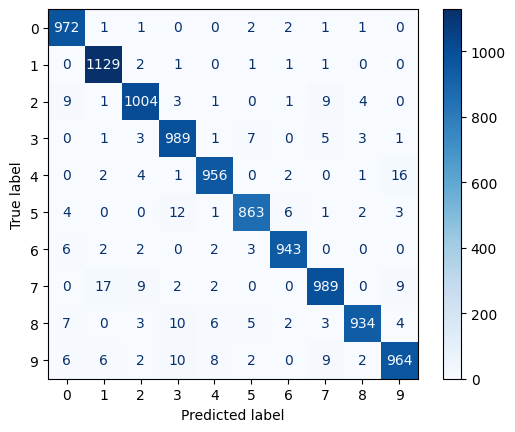

In [81]:
cm = confusion_matrix(y_test, y_pred, labels=voting_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=voting_clf.classes_)
disp.plot(cmap=plt.cm.Blues)

##### Soft Voting

In [82]:
voting_clf = VotingClassifier([("svm_clf", svm), 
                           ("knn_clf", knn), 
                           ("log_reg_clf", log_reg)
                           ], voting="soft")

In [83]:
voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm_clf', ...), ('knn_clf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",50
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [84]:
y_pred = voting_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.99      0.97      0.98       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



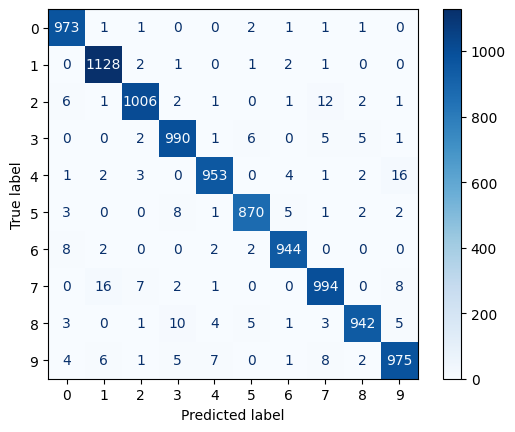

In [85]:
cm = confusion_matrix(y_test, y_pred, labels=voting_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=voting_clf.classes_)
disp.plot(cmap=plt.cm.Blues)